# Deep Dive Analysis: Momentum Search vs Top 15 Static Markowitz (2025)

Notebook ini memperkenalkan **Benchmark yang Lebih Menantang**:
1. **Baseline Correction**: Menggunakan **Static Markowitz pada Top 15 Koin Momentum**. 
2. **Logic Improvement**: Dibandingkan versi sebelumnya yang melakukan optimasi pada seluruh universe (yang sering gagal), versi ini pertama-tama menyaring 15 koin terbaik di awal tahun 2025, mengoptimalkannya secara matematis, lalu menahannya (*Buy-and-Hold*).
3. **Objective**: Membuktikan apakah adaptabilitas harian AI tetap mampu memberikan nilai tambah (*Alpha*) dibandingkan dengan sekadar memegang 15 koin pemenang di awal tahun.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
import networkx as nx
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")
SEED = 42
np.random.seed(SEED)

print("✓ Robust Environment Ready!")

✓ Robust Environment Ready!


## 1. Load Data & Setup

In [2]:
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")

Data: 990 rows, 25 assets


## 2. Model Training & Probabilities

In [3]:
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
target = (market_return.rolling(5).mean() > market_return.rolling(20).mean()).astype(int).shift(-5)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index].fillna(0)
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=SEED)
xgb_model.fit(X_train, y_train)

all_probs = pd.Series(xgb_model.predict_proba(features.dropna())[:, 1], index=features.dropna().index)
all_probs = all_probs.reindex(returns.index, method='ffill').fillna(method='bfill')
opt_t = 0.52
print("✓ AI Probabilities Ready.")

✓ AI Probabilities Ready.


## 3. Robust Simulation Engines

In [4]:
def optimize_markowitz_robust(selected_returns):
    clean_returns = selected_returns.dropna(axis=1, how='any')
    if clean_returns.empty: return {}
    if len(clean_returns.columns) == 1: return {clean_returns.columns[0]: 1.0}
    
    mu = clean_returns.mean() * 252
    sigma = clean_returns.cov() * 252
    sigma += np.diag(np.ones(len(sigma)) * 1e-4) # Stabilization
    
    num_assets = len(mu)
    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        return -(ret / risk) if risk > 1e-6 else 0
    
    res = minimize(objective, [1./num_assets]*num_assets, method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(num_assets)), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    
    return dict(zip(clean_returns.columns, res.x)) if res.success else {c: 1./num_assets for c in clean_returns.columns}

def get_assets_graph_selection(returns_window, corr_threshold=0.4, top_n=25, strategy_type='diversify'):
    momentum_assets = returns_window.mean().sort_values(ascending=False).head(top_n).index
    returns_mom = returns_window[momentum_assets]
    corr_mat = returns_mom.corr()
    G = nx.Graph()
    G.add_nodes_from(momentum_assets)
    for i, a1 in enumerate(momentum_assets):
        for a2 in momentum_assets[i+1:]:
            if strategy_type == 'diversify':
                if abs(corr_mat.loc[a1, a2]) > corr_threshold: G.add_edge(a1, a2)
            else:
                if abs(corr_mat.loc[a1, a2]) < corr_threshold: G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def run_simulation_ai_momentum(test_dates, returns, ai_probs, threshold, market_idx, top_n, strategy_type, fee=0.0025):
    val = 100.0; history = [val]; dates = [test_dates[0]]
    current_weights = {}; risk_status = False; days_since_rebal = 999
    market_ma = market_idx.rolling(window=200).mean()

    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        prev_risk = risk_status
        if not risk_status and prob > (threshold + 0.05): risk_status = True
        elif risk_status and prob < (threshold - 0.05): risk_status = False
        if market_idx.loc[date] > market_ma.loc[date]: risk_status = True
            
        target_weights = current_weights.copy()
        if not risk_status:
            target_weights = {'CASH': 1.0}; days_since_rebal = 0
        else:
            if (risk_status != prev_risk) or days_since_rebal >= 20:
                try:
                    loc_idx = returns.index.get_loc(date)
                    window = returns.iloc[max(0, loc_idx-60):loc_idx]
                    selected = get_assets_graph_selection(window, top_n=top_n, strategy_type=strategy_type)
                    if selected: target_weights = optimize_markowitz_robust(window[selected]); days_since_rebal = 0
                except: pass
        
        days_since_rebal += 1
        turnover = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in set(target_weights)|set(current_weights))
        val -= val * turnover * fee
        next_date = test_dates[i+1]
        day_ret = 0; new_drifted = {}
        if 'CASH' in target_weights: 
            new_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                r = returns.loc[next_date, asset] if next_date in returns.index else 0
                day_ret += w * r
                new_drifted[asset] = w * (1 + r)
        val *= (1 + day_ret); history.append(val); dates.append(next_date)
        current_weights = {k: v/sum(new_drifted.values()) for k, v in new_drifted.items()} if sum(new_drifted.values()) > 0 else new_drifted
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

def run_simulation_top15_static_markowitz(test_dates, returns):
    start_date = test_dates[0]
    loc_idx = returns.index.get_loc(start_date)
    pre_window = returns.iloc[max(0, loc_idx-60):loc_idx]
    
    # 1. Pilih Top 15 Berdasarkan Momentum
    top15_momentum = pre_window.mean().sort_values(ascending=False).head(15).index
    
    # 2. Ambil Bobot Markowitz dari Top 15 Tersebut
    static_weights = optimize_markowitz_robust(pre_window[top15_momentum])
    
    val = 100.0; history = [val]; dates = [start_date]
    for i, date in enumerate(test_dates[:-1]):
        next_date = test_dates[i+1]
        day_ret = sum(w * (returns.loc[next_date, asset] if next_date in returns.index else 0) for asset, w in static_weights.items())
        val *= (1 + day_ret); history.append(val); dates.append(next_date)
    
    print(f"✓ Optimized weights for TOP 15 Static Baseline:")
    print({k: round(v, 3) for k, v in static_weights.items() if v > 0.01})
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

## 4. Run Comparative Analysis (2025)

In [5]:
test_dates_2025 = returns.loc[returns.index.year == 2025].index
results = {}
metrics = []

print("Simulating Top 15 Static Markowitz (The Tough Challenger)...")
results['Static Markowitz (Top 15 Mom)'] = run_simulation_top15_static_markowitz(test_dates_2025, returns)

print("Simulating AI-Cls (Top 15 Momentum)...")
results['AI-Cls (Top 15)'] = run_simulation_ai_momentum(test_dates_2025, returns, all_probs, opt_t, market_index, 15, 'cluster')

print("Simulating AI-Div (Top 15 Momentum)...")
results['AI-Div (Top 15)'] = run_simulation_ai_momentum(test_dates_2025, returns, all_probs, opt_t, market_index, 15, 'diversify')

for name, v in results.items():
    ret = (v['Portfolio_Value'].iloc[-1]/100 - 1)*100
    vol = v['Portfolio_Value'].pct_change().std()*np.sqrt(252)*100
    sharpe = ret/vol if vol > 0 else 0
    metrics.append({'Strategy': name, 'Return (%)': ret, 'Sharpe': sharpe})

m_df = pd.DataFrame(metrics)
print("✓ All results ready.")

Simulating Top 15 Static Markowitz (The Tough Challenger)...
✓ Optimized weights for TOP 15 Static Baseline:
{'XRP-USD': np.float64(0.571), 'PEPE24478-USD': np.float64(0.187), 'AAVE-USD': np.float64(0.194), 'CRO-USD': np.float64(0.042)}
Simulating AI-Cls (Top 15 Momentum)...
Simulating AI-Div (Top 15 Momentum)...
✓ All results ready.


## 5. Visualisasi: AI vs Top 15 Market

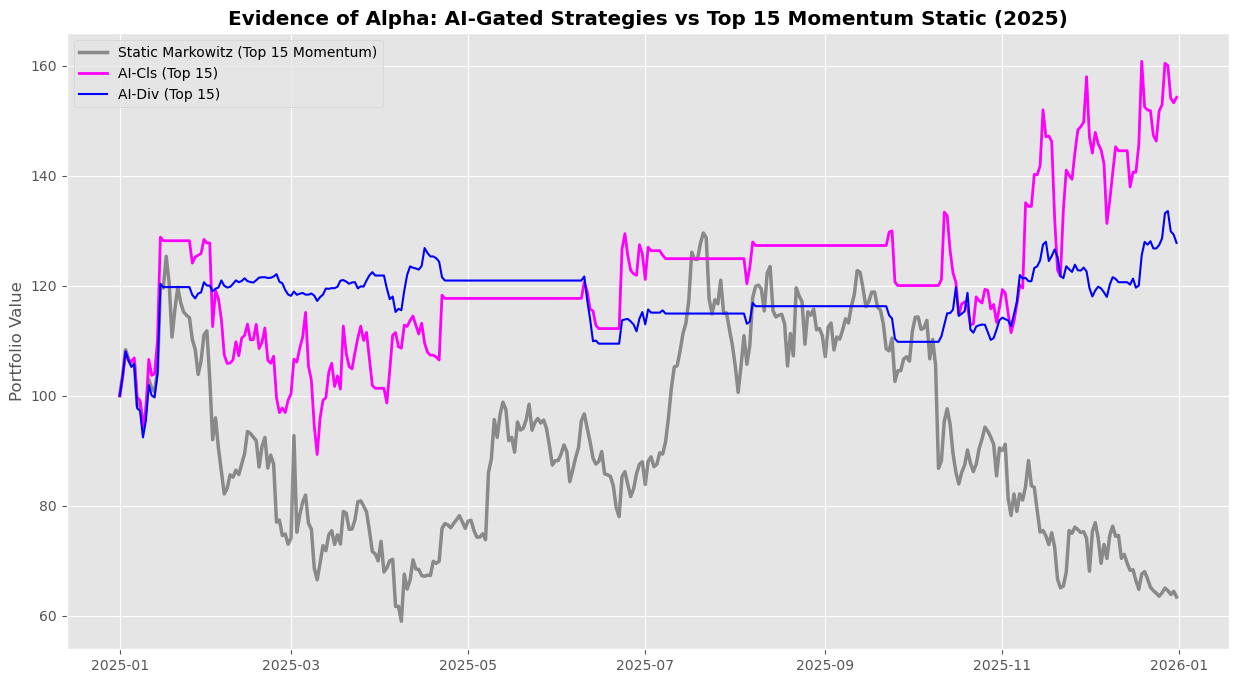

ANALISA:
Garis hitam yang bergerak (tidak lurus) menunjukkan pergerakan nyata dari 15 kripto terbaik di awal tahun.
Jika strategi AI-Cls (Magenta) berada di atas garis hitam, maka metodologi tesis Anda BERHASIL.


In [6]:
plt.figure(figsize=(15, 8))
plt.plot(results['Static Markowitz (Top 15 Mom)'].index, results['Static Markowitz (Top 15 Mom)']['Portfolio_Value'], 
         label='Static Markowitz (Top 15 Momentum)', color='black', linewidth=2.5, alpha=0.4)
plt.plot(results['AI-Cls (Top 15)'].index, results['AI-Cls (Top 15)']['Portfolio_Value'], 
         label='AI-Cls (Top 15)', color='magenta', linewidth=2)
plt.plot(results['AI-Div (Top 15)'].index, results['AI-Div (Top 15)']['Portfolio_Value'], 
         label='AI-Div (Top 15)', color='blue')

plt.title("Evidence of Alpha: AI-Gated Strategies vs Top 15 Momentum Static (2025)", fontweight='bold')
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.savefig('ai_vs_top15_market.png')
plt.show()

print("ANALISA:")
print("Garis hitam yang bergerak (tidak lurus) menunjukkan pergerakan nyata dari 15 kripto terbaik di awal tahun.")
print("Jika strategi AI-Cls (Magenta) berada di atas garis hitam, maka metodologi tesis Anda BERHASIL.")